# Sequential Repeater Analysis Plots

Run the **Setup** cell first, then each plot cell independently.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sequential_repeaters_dist import (
    RepeaterParams, QuantumRepeaterNetwork,
    build_s2_graph, build_graph, binary_entropy, BBPSSW
)

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
PALETTE = sns.color_palette('tab10')

def make_params(**overrides):
    """Return a RepeaterParams with standard values, optionally overridden."""
    p = RepeaterParams()
    p.p_det     = 0.95
    p.alpha     = 0.18
    p.q_0       = 0.01
    p.nu        = 1e9
    p.R_dark    = 100
    p.delta_det = 100e-12
    p.p_pair    = 0.05
    p.eta_c     = 0.8
    p.P_BSM     = 0.5
    p.T_coh     = 0.05      # memory coherence time [s]
    for k, v in overrides.items():
        setattr(p, k, v)
    return p

N    = 1000
BETA = 2.6261
MU   = 0.0233

print('Building graphs (slow — run once) ...')
A_city,    dist_city,    coords_city    = build_s2_graph(N, BETA, MU, scale='city')
A_country, dist_country, coords_country = build_s2_graph(N, BETA, MU, scale='country')
A_europe,  dist_europe,  coords_europe  = build_s2_graph(N, BETA, MU, scale='europe')
A_custom,  dist_custom                  = build_graph(n_hubs=10, avg_n_branches=5)
print('Done.')

params = make_params()

def make_net(A, dist, coords, scale, distillation_type=None):
    """Convenience wrapper: build a network with standard params."""
    return QuantumRepeaterNetwork(
        params, A, dist, coords,
        architecture='node', scale=scale,
        distillation_type=distillation_type,
    )

net_city    = make_net(A_city,    dist_city,    coords_city,    'city')
net_country = make_net(A_country, dist_country, coords_country, 'country')
net_europe  = make_net(A_europe,  dist_europe,  coords_europe,  'europe')
net_custom  = make_net(A_custom,  dist_custom,  None,           1.0)

NETWORKS = [
    ('S2 city',    net_city,    PALETTE[0]),
    ('S2 country', net_country, PALETTE[1]),
    ('S2 europe',  net_europe,  PALETTE[2]),
    ('Custom',     net_custom,  PALETTE[3]),
]

SOURCE = 0
print('All networks ready.')

Building graphs (slow — run once) ...
Done.
All networks ready.


## Synthetic path helpers

These replicate the logic of `calculate_metrics` analytically for a chain of
`n_hops` equal links spanning `total_dist_km`, without needing a graph.
They support the same `architecture` and `distillation_type` options as the
class, including coherence decay between hops.

In [2]:
def _link_eta(params, link_dist_km, architecture):
    """Return (eta_A, eta_B) for a single synthetic link."""
    p = params
    if architecture == 'midpoint':
        eta = p.eta_c * p.p_det * 10 ** (-p.alpha * (link_dist_km / 2) / 10)
        return eta, eta
    elif architecture == 'node':
        eta_A = p.eta_c * p.p_det
        eta_B = p.eta_c * p.p_det * 10 ** (-p.alpha * link_dist_km / 10)
        return eta_A, eta_B
    else:
        raise ValueError("architecture must be 'node' or 'midpoint'")


def _link_q(params, link_dist_km, architecture):
    """Per-link QBER for a synthetic link."""
    p = params
    eta_A, eta_B = _link_eta(p, link_dist_km, architecture)
    p_dc   = p.R_dark * p.delta_det
    p_acc  = (p.p_pair * eta_A * (1 - eta_B) * p_dc
              + p.p_pair * eta_B * (1 - eta_A) * p_dc
              + p_dc ** 2)
    p_true = p.p_pair * eta_A * eta_B
    if p_true + p_acc == 0:
        return 0.5
    return (p_true * (p.q_0 + p.p_pair / 2) + 0.5 * p_acc) / (p_true + p_acc)


def _link_qber_components(params, link_dist_km, architecture):
    """
    Return the four additive contributions to the per-link QBER numerator,
    each normalised by the denominator (p_true + p_acc), so they sum to Q_link.

    Keys: 'baseline', 'multiphoton', 'dc_mixed', 'dc_both', 'denominator'
    """
    p = params
    eta_A, eta_B = _link_eta(p, link_dist_km, architecture)
    p_dc   = p.R_dark * p.delta_det
    p_true = p.p_pair * eta_A * eta_B
    p_acc  = (p.p_pair * eta_A * (1 - eta_B) * p_dc
              + p.p_pair * eta_B * (1 - eta_A) * p_dc
              + p_dc ** 2)
    denom  = p_true + p_acc
    return {
        'baseline':    p_true * p.q_0,
        'multiphoton': p_true * p.p_pair / 2,
        'dc_mixed':    0.5 * (p.p_pair * eta_A * (1 - eta_B)
                              + p.p_pair * eta_B * (1 - eta_A)) * p_dc,
        'dc_both':     0.5 * p_dc ** 2,
        'denominator': denom,
    }


def _synthetic_metrics(params, total_dist_km, n_hops,
                        architecture='midpoint', distillation_type=None):
    """
    Compute (T, QBER, SKR) for a synthetic equal-hop chain.

    Mirrors calculate_metrics: coherence decay and optional BBPSSW
    distillation are applied at each hop exactly as in the class.

    Parameters
    ----------
    params           : RepeaterParams
    total_dist_km    : float
    n_hops           : int
    architecture     : 'node' or 'midpoint'
    distillation_type : None, 'multiplexing', or 'standard'

    Returns
    -------
    T    : float   total expected rounds (np.nan if no signal)
    QBER : float
    SKR  : float   [bit/s]
    """
    p         = params
    link_dist = total_dist_km / n_hops
    eta_A, eta_B = _link_eta(p, link_dist, architecture)
    p_ent     = p.p_pair * eta_A * eta_B

    if p_ent <= 0:
        return np.nan, np.nan, np.nan

    T_link = 1.0 / p_ent
    Q_link = _link_q(p, link_dist, architecture)

    # ── first link ───────────────────────────────────────────────────
    T = T_link
    W = 1 - 2 * Q_link

    # ── subsequent links — same logic as calculate_metrics ───────────
    for _ in range(n_hops - 1):
        T = (T + T_link) / p.P_BSM
        W_swap = W * np.exp(-(T_link/ params.nu) / p.T_coh) * (1 - 2 * Q_link)
        if distillation_type == 'multiplexing':
            F1 = F2 = (1 + 3 * W_swap) / 4
            F_out, P_suc = BBPSSW(F1, F2)
            T = T / P_suc
            W = (4 * F_out - 1) / 3
        elif distillation_type == 'standard':
            W1 = W_swap * np.exp(-(T/ params.nu) / p.T_coh)
            F1 = (1 + 3 * W1)     / 4
            F2 = (1 + 3 * W_swap) / 4
            F_out, P_suc = BBPSSW(F1, F2)
            T = 2 * T / P_suc
            W = (4 * F_out - 1) / 3

        elif distillation_type is None:
            W = W_swap

        else:
            raise ValueError("distillation_type must be 'multiplexing', 'standard', or None")

    QBER  = (1 - W) / 2
    R     = 0.5 * p.nu / T
    SKR   = R * (1 - 2 * binary_entropy(QBER))
    return T, QBER, SKR


# Convenience wrappers used by plotting functions
def _synthetic_qber(params, total_dist_km, n_hops,
                    architecture='midpoint', distillation_type=None):
    _, Q, _ = _synthetic_metrics(params, total_dist_km, n_hops,
                                  architecture, distillation_type)
    return Q

def _synthetic_skr(params, total_dist_km, n_hops,
                   architecture='midpoint', distillation_type=None):
    _, _, SKR = _synthetic_metrics(params, total_dist_km, n_hops,
                                    architecture, distillation_type)
    return SKR

print('Synthetic helpers defined.')

Synthetic helpers defined.


## Plot 1 — SKR vs P_BSM (4 subplots, adaptive hop lines)

Each subplot = one network.  One line per hop count (adaptive up to `max_hops`).
For each P_BSM value, the best SKR among all paths of exactly that hop count
is shown, using `calculate_metrics` with the current `distillation_type`.

  S2 city ...
  S2 country ...
  S2 europe ...
  Custom ...


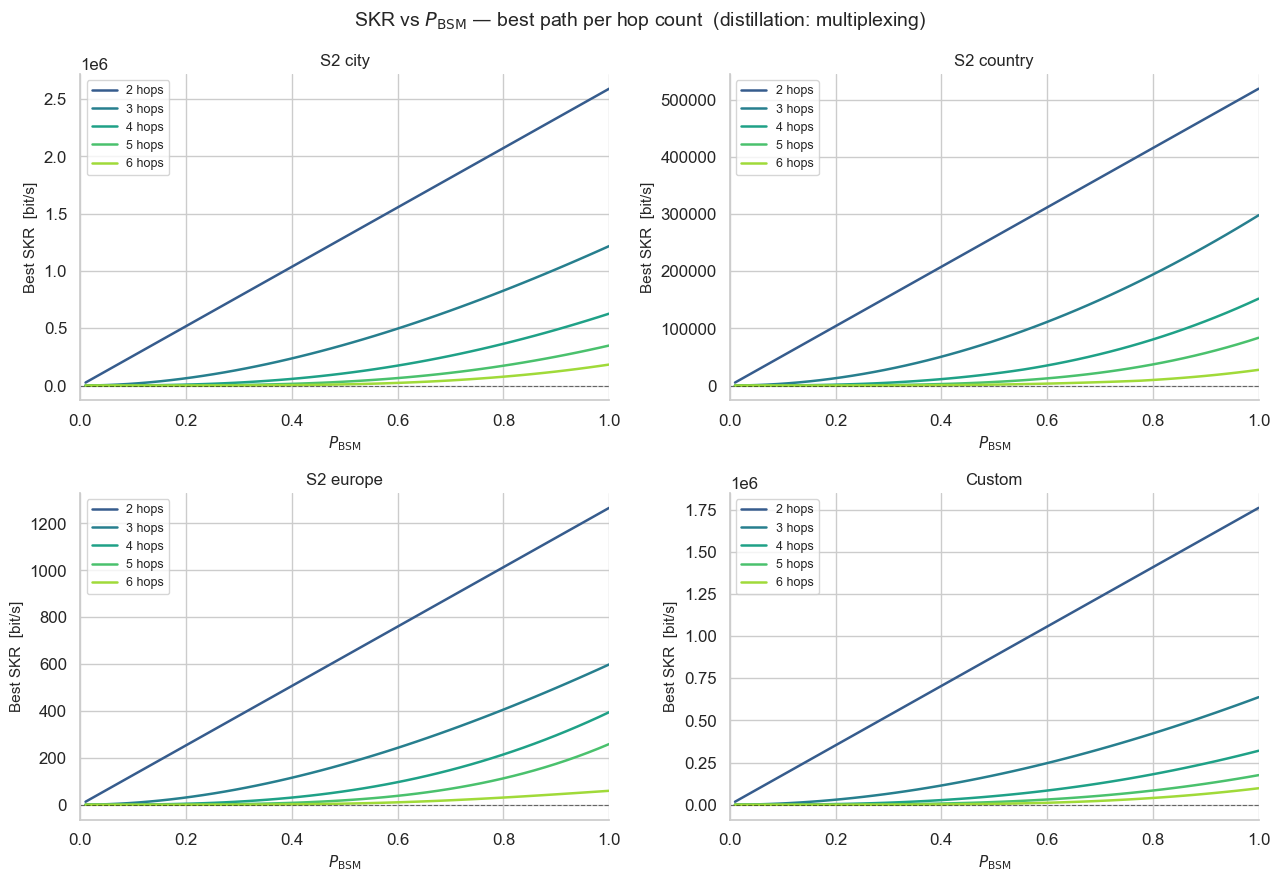

In [3]:
def _paths_by_hopcount(net, source):
    """Dict mapping hop_count -> list of paths with that hop count."""
    _, paths = net.optimal_path(source)
    paths.pop(source, None)
    by_hops = {}
    for path in paths.values():
        n = len(path) - 1
        by_hops.setdefault(n, []).append(path)
    return by_hops


def plot_skr_vs_pbsm_subplots(networks, source=0, n_points=50,
                               max_hops=6, distillation_type=None):
    """
    4-subplot SKR vs P_BSM figure.

    Parameters
    ----------
    networks         : list of (label, QuantumRepeaterNetwork, colour)
    source           : int
    n_points         : int    number of P_BSM values
    max_hops         : int    maximum hop count to show
    distillation_type : None, 'multiplexing', or 'standard'
    """
    pbsm_vals   = np.linspace(0.01, 1.0, n_points)
    hop_palette = sns.color_palette('viridis', max_hops)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    for ax, (label, net, _) in zip(axes, networks):
        print(f'  {label} ...')
        by_hops    = _paths_by_hopcount(net, source)
        hop_counts = sorted(h for h in by_hops if h <= max_hops and h != 1)

        for hop_n in hop_counts:
            path_list = by_hops[hop_n]
            best_skrs = []

            for pbsm in pbsm_vals:
                p_new = make_params(P_BSM=pbsm)
                net_tmp = QuantumRepeaterNetwork(
                    p_new, net.A, net.dist, net.coords,
                    architecture=net.architecture,
                    scale=net.scale_km,
                    distillation_type=distillation_type,
                )
                skrs = [net_tmp.calculate_metrics(p)[2] for p in path_list]
                best_skrs.append(max(skrs))

            ax.plot(pbsm_vals, best_skrs,
                    color=hop_palette[hop_n - 1], linewidth=1.8,
                    label=f'{hop_n} hop{"s" if hop_n > 1 else ""}')

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_title(label, fontsize=12)
        ax.set_xlabel(r'$P_{\mathrm{BSM}}$', fontsize=11)
        ax.set_ylabel('Best SKR  [bit/s]', fontsize=11)
        ax.legend(fontsize=9, frameon=True)
        ax.set_xlim(0, 1)
        sns.despine(ax=ax)

    dist_str = distillation_type if distillation_type else 'none'
    fig.suptitle(f'SKR vs $P_{{\\mathrm{{BSM}}}}$ — best path per hop count  '
                 f'(distillation: {dist_str})', fontsize=14)
    plt.tight_layout()
    plt.savefig('plot1_skr_vs_pbsm.pdf', bbox_inches='tight')
    plt.show()


plot_skr_vs_pbsm_subplots(NETWORKS, source=SOURCE, distillation_type='multiplexing')

## Plot 2 — QBER vs number of hops (alpha = 0)

With zero fibre loss, QBER depends only on dark counts and intrinsic errors,
revealing the theoretical maximum number of hops regardless of distance.

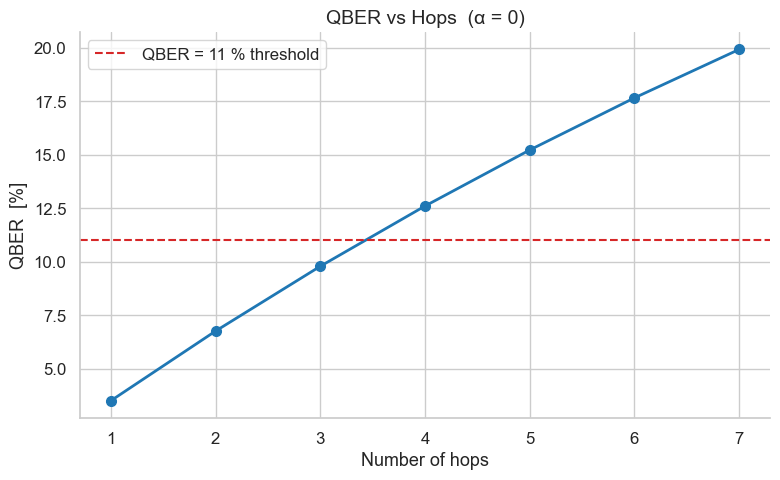

In [4]:
def plot_qber_vs_hops(net, source=0, max_hops=None, distillation_type=None):
    """
    QBER vs hop count with alpha=0.  One representative path per hop count.

    Parameters
    ----------
    net              : QuantumRepeaterNetwork
    source           : int
    max_hops         : int or None
    distillation_type : None, 'multiplexing', or 'standard'
    """
    QBER_THRESHOLD = 0.11

    p_no_loss = make_params(alpha=0.00)
    net_nl = QuantumRepeaterNetwork(
        p_no_loss, net.A, net.dist, net.coords,
        architecture=net.architecture, scale=net.scale_km,
        distillation_type=distillation_type,
    )

    _, paths = net_nl.optimal_path(source)
    paths.pop(source, None)

    rep_by_hops = {}
    for path in paths.values():
        n = len(path) - 1
        if n not in rep_by_hops:
            rep_by_hops[n] = path

    hop_counts = sorted(rep_by_hops)
    if max_hops is not None:
        hop_counts = [h for h in hop_counts if h <= max_hops]

    # calculate_metrics returns (T, QBER, SKR)
    qbers = [net_nl.calculate_metrics(rep_by_hops[h])[1] * 100
             for h in hop_counts]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hop_counts, qbers, marker='o', linewidth=2,
            color=PALETTE[0], markersize=7)
    ax.axhline(QBER_THRESHOLD * 100, color=PALETTE[3], linewidth=1.5,
               linestyle='--', label='QBER = 11 % threshold')
    ax.set_xlabel('Number of hops', fontsize=13)
    ax.set_ylabel('QBER  [%]', fontsize=13)
    dist_str = distillation_type if distillation_type else 'none'
    #ax.set_title(f'QBER vs Hops  (α = 0, distillation: {dist_str})', fontsize=14)
    ax.set_title(f'QBER vs Hops  (α = 0)', fontsize=14)
    ax.set_xticks(hop_counts)
    ax.legend(frameon=True)
    ax.set_xlim(min(hop_counts) - 0.3, max(hop_counts) + 0.3)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'plots/plot2_qber_vs_hops.pdf', bbox_inches='tight')
    plt.show()


plot_qber_vs_hops(net_country, source=SOURCE, distillation_type=None)

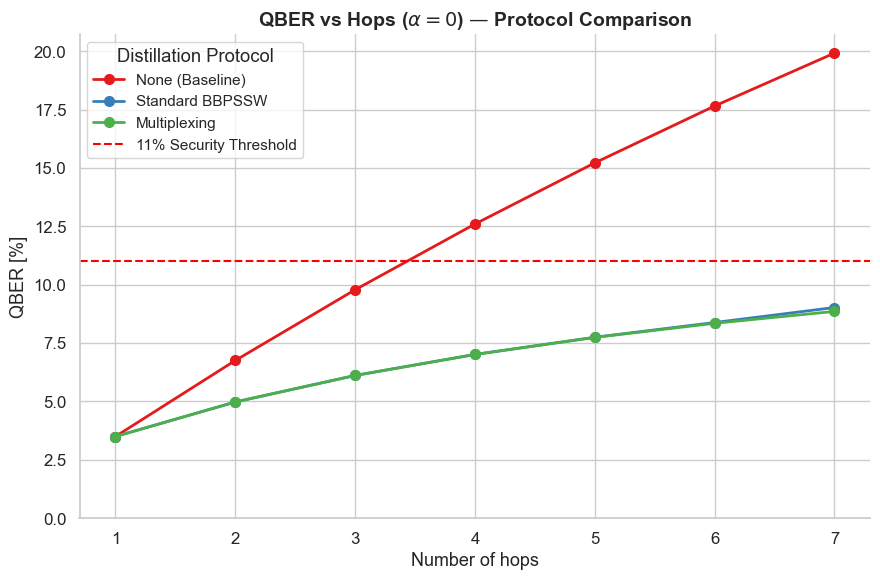

In [13]:
def plot_qber_vs_hops_all_dist(net, source=0, max_hops=None):
    """
    QBER vs hop count with alpha=0, comparing all distillation protocols
    on the same representative paths.

    Parameters
    ----------
    net              : QuantumRepeaterNetwork
    source           : int
    max_hops         : int or None
    """
    QBER_THRESHOLD = 0.11
    dist_types = [None, 'standard', 'multiplexing']
    labels = ['None (Baseline)', 'Standard BBPSSW', 'Multiplexing']

    # Use a distinct color palette for the 3 lines
    palette = sns.color_palette("Set1", len(dist_types))

    # 1. Generate parameters with zero fiber loss
    p_no_loss = make_params(alpha=0.0)

    # 2. Extract representative paths ONCE so all protocols are evaluated fairly
    net_base = QuantumRepeaterNetwork(
        p_no_loss, net.A, net.dist, net.coords,
        architecture=net.architecture, scale=net.scale_km,
        distillation_type=None,
    )

    _, paths = net_base.optimal_path(source)
    paths.pop(source, None)

    rep_by_hops = {}
    for path in paths.values():
        n = len(path) - 1
        if n not in rep_by_hops:
            rep_by_hops[n] = path

    hop_counts = sorted(rep_by_hops)
    if max_hops is not None:
        hop_counts = [h for h in hop_counts if h <= max_hops]

    # 3. Setup the plot
    fig, ax = plt.subplots(figsize=(9, 6))

    # 4. Loop over each distillation type and plot its QBER line
    for idx, dist_type in enumerate(dist_types):
        # Initialize network engine for this specific protocol
        net_eval = QuantumRepeaterNetwork(
            p_no_loss, net.A, net.dist, net.coords,
            architecture=net.architecture, scale=net.scale_km,
            distillation_type=dist_type,
        )

        # Calculate metrics for the representative paths
        qbers = [net_eval.calculate_metrics(rep_by_hops[h])[1] * 100
                 for h in hop_counts]

        ax.plot(hop_counts, qbers, marker='o', linewidth=2,
                color=palette[idx], markersize=7, label=labels[idx])

    # 5. Graph Formatting
    ax.axhline(QBER_THRESHOLD * 100, color='red', linewidth=1.5,
               linestyle='--', label='11% Security Threshold')

    ax.set_xlabel('Number of hops', fontsize=13)
    ax.set_ylabel('QBER [%]', fontsize=13)
    ax.set_title(r'QBER vs Hops ($\alpha = 0$) — Protocol Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(hop_counts)
    ax.set_xlim(min(hop_counts) - 0.3, max(hop_counts) + 0.3)

    # Start Y-axis at 0 for cleaner visual representation of error
    ax.set_ylim(bottom=0)

    ax.legend(title='Distillation Protocol', frameon=True, fontsize=11)
    sns.despine()
    plt.tight_layout()

    # Save the file (forced to pdf to avoid OS bugs)
    plt.savefig('plots/plot2_qber_vs_hops_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Run the function
plot_qber_vs_hops_all_dist(net_city, source=SOURCE, max_hops=12)

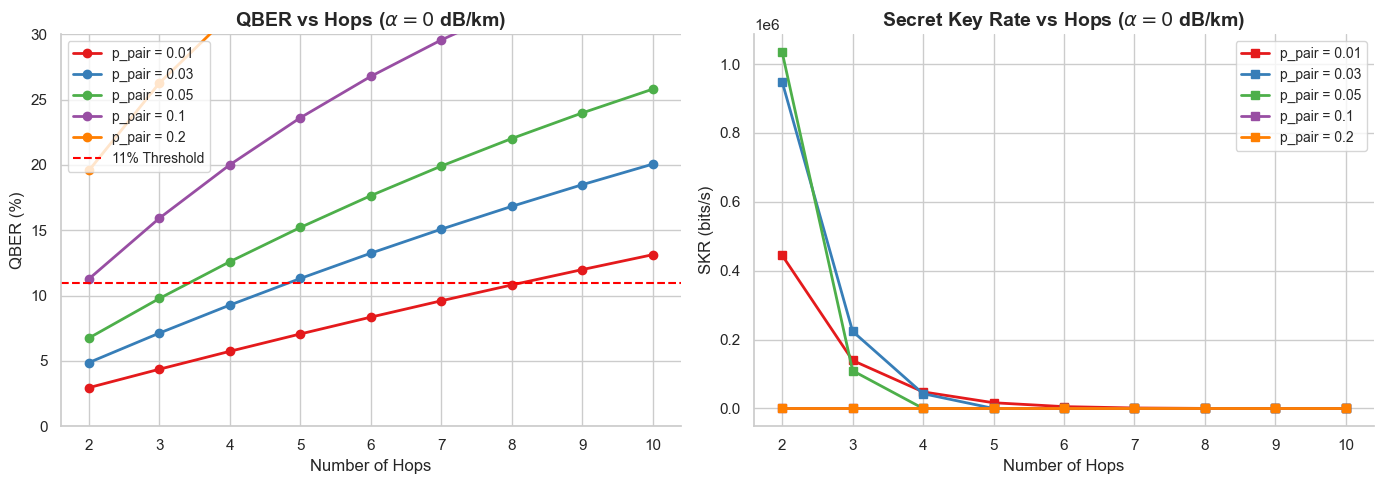

In [93]:
# ---------------------------------------------------------------------------
# CELL: Parameter Sweep for p_pair Tradeoff (alpha = 0)
# ---------------------------------------------------------------------------

import scipy.spatial.distance as spdist

# 1. Setup a clean Linear Graph to isolate hop distance
N_nodes = 15
# Distance is arbitrary since alpha=0, but we use 10km spacing for matrix shape
coords_linear = np.array([[i*50, 0] for i in range(N_nodes)])
dist_linear = spdist.squareform(spdist.pdist(coords_linear))
A_linear = np.zeros((N_nodes, N_nodes))
for i in range(N_nodes-1):
    A_linear[i, i+1] = 1
    A_linear[i+1, i] = 1

# 2. Setup Parameters with ZERO fiber loss
params_sweep = RepeaterParams()
params_sweep.p_det = 0.95
params_sweep.alpha = 0.00          # Lossless channel to isolate source/memory dynamics
params_sweep.q_0 = 0.01
params_sweep.nu = 1e9
params_sweep.R_dark = 100
params_sweep.delta_det = 100e-12
params_sweep.eta_c = 0.8
params_sweep.P_BSM = 0.5
params_sweep.T_coh = 0.05         # 50 ms coherence time

# 3. Define the values we want to test
p_pairs_to_test = [0.01, 0.03, 0.05, 0.10, 0.20]
max_hops = 10
hops_list = list(range(2, max_hops + 1))

results_qber = {p: [] for p in p_pairs_to_test}
results_skr = {p: [] for p in p_pairs_to_test}

# 4. Run the simulations
for p in p_pairs_to_test:
    params_sweep.p_pair = p

    # Initialize network with standard pumping distillation
    net_sweep = QuantumRepeaterNetwork(
        params_sweep, A_linear, dist_linear, coords_linear,
        architecture='node', scale='city', distillation_type=None
    )

    for h in hops_list:
        # Create a sequential path of length 'h' hops (e.g., [0, 1, 2])
        path = list(range(h + 1))

        # Calculate metrics using your rigorous Entanglement Pumping loop
        T, QBER, SKR = net_sweep.calculate_metrics(path)

        results_qber[p].append(QBER)
        results_skr[p].append(SKR)

# 5. Plotting the Tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")
colors = sns.color_palette("Set1", len(p_pairs_to_test))

# --- Plot 1: QBER vs Hops ---
for idx, p in enumerate(p_pairs_to_test):
    axes[0].plot(hops_list, [q * 100 for q in results_qber[p]],
                 marker='o', markersize=6, linewidth=2, color=colors[idx], label=f'p_pair = {p}')

# Add BB84 Security Threshold
axes[0].axhline(y=11.0, color='red', linestyle='--', linewidth=1.5, label='11% Threshold')

axes[0].set_title(r'QBER vs Hops ($\alpha = 0$ dB/km)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Hops', fontsize=12)
axes[0].set_ylabel('QBER (%)', fontsize=12)
axes[0].set_ylim(0, 30)
axes[0].set_xticks(hops_list)
axes[0].legend(fontsize=10, loc='upper left')

# --- Plot 2: SKR vs Hops ---
for idx, p in enumerate(p_pairs_to_test):
    # Mask out zero SKR for log plotting
    skr_vals = [s if s > 0 else 1e-20 for s in results_skr[p]]
    axes[1].plot(hops_list, skr_vals,
                 marker='s', markersize=6, linewidth=2, color=colors[idx], label=f'p_pair = {p}')

axes[1].set_title(r'Secret Key Rate vs Hops ($\alpha = 0$ dB/km)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Hops', fontsize=12)
axes[1].set_ylabel('SKR (bits/s)', fontsize=12)
#axes[1].set_yscale('log')
#axes[1].set_ylim(1e-3, 1e6)
axes[1].set_xticks(hops_list)
axes[1].legend(fontsize=10)

sns.despine()
plt.tight_layout()

# Save the plot explicitly avoiding Windows character bugs
plt.savefig('plots/plot_tradeoff_p_pair_sweep.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Plot 3a — QBER vs hops at fixed total distance

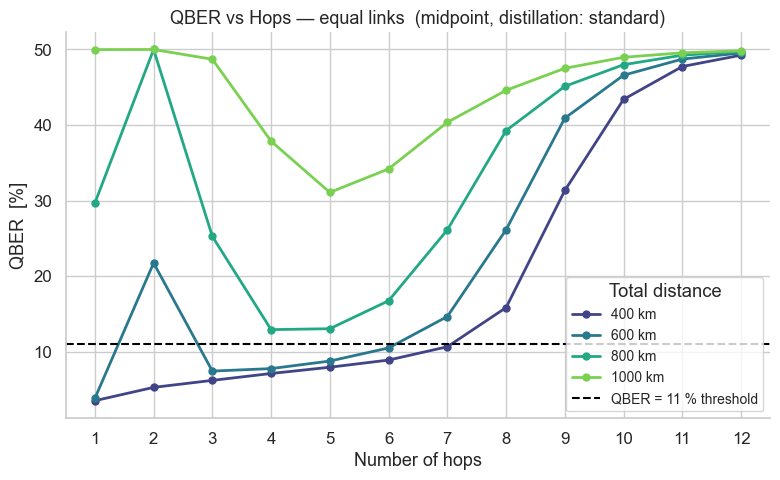

In [28]:
def plot_qber_vs_hops_fixed_dist(
        params,
        distances_km=(400, 600, 800, 1000),
        max_hops=12,
        architecture='midpoint',
        distillation_type=None):
    """
    QBER vs hops for several fixed total distances (synthetic equal-hop paths).

    Parameters
    ----------
    params           : RepeaterParams
    distances_km     : iterable of float
    max_hops         : int
    architecture     : 'node' or 'midpoint'
    distillation_type : None, 'multiplexing', or 'standard'
    """
    QBER_THRESHOLD = 0.11
    hop_range = range(1, max_hops + 1)
    palette   = sns.color_palette('viridis', len(distances_km))

    fig, ax = plt.subplots(figsize=(8, 5))
    for dist_km, colour in zip(distances_km, palette):
        qbers = [
            _synthetic_qber(params, dist_km, h, architecture, distillation_type) * 100
            for h in hop_range
        ]
        ax.plot(list(hop_range), qbers, marker='o', linewidth=2,
                color=colour, markersize=5, label=f'{dist_km} km')

    ax.axhline(QBER_THRESHOLD * 100, color='black', linewidth=1.5,
               linestyle='--', label='QBER = 11 % threshold')
    ax.set_xlabel('Number of hops', fontsize=13)
    ax.set_ylabel('QBER  [%]', fontsize=13)
    dist_str = distillation_type if distillation_type else 'none'
    ax.set_title(
        f'QBER vs Hops — equal links  ({architecture}, distillation: {dist_str})',
        fontsize=13)
    ax.set_xticks(list(hop_range))
    ax.legend(title='Total distance', frameon=True, fontsize=10)
    ax.set_xlim(0.5, max_hops + 0.5)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"plots/plot3a_qber_vs_hops_fixed_dist_{distillation_type}.pdf", bbox_inches='tight')
    plt.show()


plot_qber_vs_hops_fixed_dist(params, distillation_type='standard')

## Plot 3a (extra) — QBER error contributions vs hops

Stacked area: which physical process dominates the per-link QBER at each hop
count for a fixed total distance.

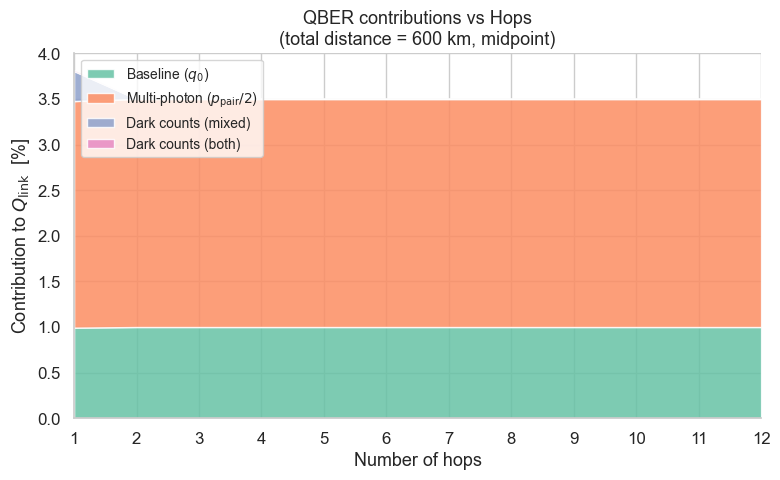

In [19]:
def plot_qber_contributions(
        params,
        total_dist_km=200,
        max_hops=12,
        architecture='midpoint'):
    """
    Stacked area of the four QBER contributions vs hop count.

    Each contribution is normalised by the per-link denominator
    (p_true + p_acc), so the stack sums to Q_link.

    Parameters
    ----------
    params        : RepeaterParams
    total_dist_km : float
    max_hops      : int
    architecture  : 'node' or 'midpoint'
    """
    hop_range   = list(range(1, max_hops + 1))
    baseline, multiphoton, dc_mixed, dc_both = [], [], [], []

    for h in hop_range:
        link_dist = total_dist_km / h
        c = _link_qber_components(params, link_dist, architecture)
        d = c['denominator']
        if d == 0:
            baseline.append(np.nan); multiphoton.append(np.nan)
            dc_mixed.append(np.nan); dc_both.append(np.nan)
        else:
            baseline.append(   c['baseline']    / d * 100)
            multiphoton.append(c['multiphoton'] / d * 100)
            dc_mixed.append(   c['dc_mixed']    / d * 100)
            dc_both.append(    c['dc_both']     / d * 100)

    contrib_palette = sns.color_palette('Set2', 4)
    labels = ['Baseline ($q_0$)', 'Multi-photon ($p_{\\mathrm{pair}}/2$)',
              'Dark counts (mixed)', 'Dark counts (both)']

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.stackplot(hop_range, [baseline, multiphoton, dc_mixed, dc_both],
                 labels=labels, colors=contrib_palette, alpha=0.85)
    ax.set_xlabel('Number of hops', fontsize=13)
    ax.set_ylabel('Contribution to $Q_{\\mathrm{link}}$  [%]', fontsize=13)
    ax.set_title(
        f'QBER contributions vs Hops\n'
        f'(total distance = {total_dist_km} km, {architecture})', fontsize=13)
    ax.set_xticks(hop_range)
    ax.legend(loc='upper left', frameon=True, fontsize=10)
    ax.set_xlim(1, max_hops)
    sns.despine()
    plt.tight_layout()
    plt.savefig('plot3a_qber_contributions.pdf', bbox_inches='tight')
    plt.show()


plot_qber_contributions(params, total_dist_km=600)

## Plot 3b — SKR vs hops at fixed total distance

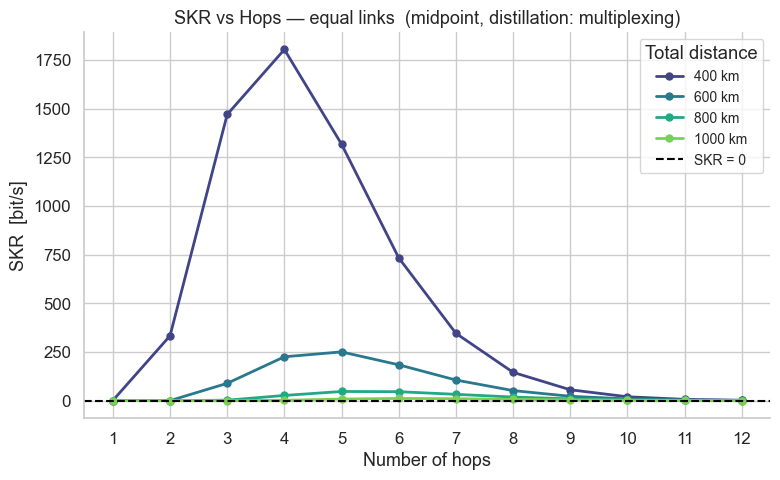

In [36]:
def plot_skr_vs_hops_fixed_dist(
        params,
        distances_km=(200, 300, 600, 700, 1000),
        max_hops=12,
        architecture='midpoint',
        distillation_type=None):
    """
    SKR vs hops for several fixed total distances (synthetic equal-hop paths).

    Parameters
    ----------
    params           : RepeaterParams
    distances_km     : iterable of float
    max_hops         : int
    architecture     : 'node' or 'midpoint'
    distillation_type : None, 'multiplexing', or 'standard'
    """
    hop_range = range(1, max_hops + 1)
    palette   = sns.color_palette('viridis', len(distances_km))

    fig, ax = plt.subplots(figsize=(8, 5))
    for dist_km, colour in zip(distances_km, palette):
        skrs = [
            _synthetic_skr(params, dist_km, h, architecture, distillation_type)
            for h in hop_range
        ]
        ax.plot(list(hop_range), skrs, marker='o', linewidth=2,
                color=colour, markersize=5, label=f'{dist_km} km')

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--', label='SKR = 0')
    ax.set_xlabel('Number of hops', fontsize=13)
    ax.set_ylabel('SKR  [bit/s]', fontsize=13)
    dist_str = distillation_type if distillation_type else 'none'
    ax.set_title(
        f'SKR vs Hops — equal links  ({architecture}, distillation: {dist_str})',
        fontsize=13)
    ax.set_xticks(list(hop_range))
    ax.legend(title='Total distance', frameon=True, fontsize=10)
    ax.set_xlim(0.5, max_hops + 0.5)
    #ax.set_yscale('log')
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"plots/plot3b_skr_vs_hops_fixed_dist_{distillation_type}.pdf", bbox_inches='tight')
    plt.show()


plot_skr_vs_hops_fixed_dist(params, distillation_type='multiplexing', distances_km=(400, 600, 800, 1000))

## Plot 4 — SKR vs total path distance (all four topologies)

  Analysing S2 city ...
  Analysing S2 country ...
  Analysing S2 europe ...
  Analysing Custom ...


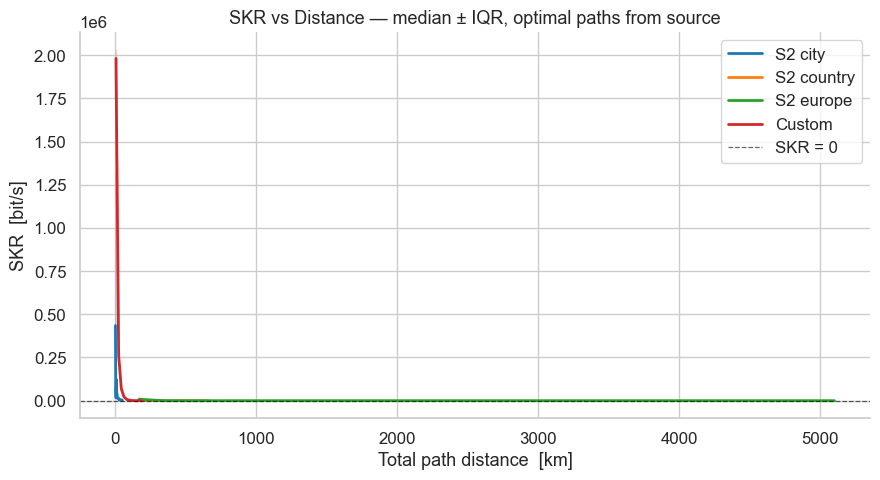

In [61]:
def plot_skr_vs_distance(networks, source=0, n_bins=30):
    """
    SKR vs total path distance, binned median ± IQR, for each network.

    Parameters
    ----------
    networks : list of (label, QuantumRepeaterNetwork, colour)
    source   : int
    n_bins   : int
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    for label, net, colour in networks:
        print(f'  Analysing {label} ...')
        df = net.analyze_all_paths(source)

        total_dists = np.array([
            sum(net.path_distances(row['path']))
            for _, row in df.iterrows()
        ])
        skrs = df['SKR'].values

        d_min, d_max = total_dists.min(), total_dists.max()
        bins = np.linspace(d_min, d_max, n_bins + 1)
        bc, med, p25, p75 = [], [], [], []

        for i in range(n_bins):
            mask = (total_dists >= bins[i]) & (total_dists < bins[i + 1])
            if mask.sum() < 2:
                continue
            vals = skrs[mask]
            bc.append((bins[i] + bins[i + 1]) / 2)
            med.append(np.median(vals))
            p25.append(np.percentile(vals, 25))
            p75.append(np.percentile(vals, 75))

        bc = np.array(bc); med = np.array(med)
        ax.plot(bc, med, color=colour, linewidth=2, label=label)
        ax.fill_between(bc, p25, p75, color=colour, alpha=0.15)

    ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.6,
               label='SKR = 0')
    ax.set_xlabel('Total path distance  [km]', fontsize=13)
    ax.set_ylabel('SKR  [bit/s]', fontsize=13)
    ax.set_title('SKR vs Distance — median ± IQR, optimal paths from source', fontsize=13)
    ax.legend(frameon=True)
    sns.despine()
    plt.tight_layout()
    plt.savefig('plot4_skr_vs_distance.pdf', bbox_inches='tight')
    plt.show()


plot_skr_vs_distance(NETWORKS, source=SOURCE)

## Plot 5 — SKR spatial heatmap (side by side)

In [ ]:
from sequential_repeaters import _sphere_to_2d
import matplotlib.colors as mcolors

def plot_skr_heatmap(net_left, label_left, net_right, label_right, source=0):
    """
    Side-by-side SKR spatial heatmap (requires coords on both networks).

    Parameters
    ----------
    net_left/right   : QuantumRepeaterNetwork  (coords must not be None)
    label_left/right : str
    source           : int
    """
    def _prepare(net):
        df      = net.analyze_all_paths(source)
        x, y    = _sphere_to_2d(net.coords, net.scale_km)
        skr_log = np.full(len(x), np.nan)
        for idx, row in df.iterrows():
            if row['SKR'] > 0:
                skr_log[int(idx)] = np.log10(row['SKR'])
        rows, cols = np.where(np.triu(net.A, k=1) > 0)
        edge_x = [v for i, j in zip(rows, cols) for v in (x[i], x[j], np.nan)]
        edge_y = [v for i, j in zip(rows, cols) for v in (y[i], y[j], np.nan)]
        return x, y, skr_log, edge_x, edge_y

    print('  Preparing panels ...')
    xl, yl, skrl, exl, eyl = _prepare(net_left)
    xr, yr, skrr, exr, eyr = _prepare(net_right)

    all_valid = np.concatenate([skrl[~np.isnan(skrl)], skrr[~np.isnan(skrr)]])
    vmin, vmax = all_valid.min(), all_valid.max()
    cmap = plt.cm.YlGn
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    def _colours(skr_log):
        out = []
        for i, v in enumerate(skr_log):
            if i == source:   out.append('gold')
            elif np.isnan(v): out.append('#555555')
            else:             out.append(cmap(norm(v)))
        return out

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, x, y, skr_log, ex, ey, lbl in [
        (axes[0], xl, yl, skrl, exl, eyl, label_left),
        (axes[1], xr, yr, skrr, exr, eyr, label_right),
    ]:
        ax.plot(ex, ey, color='#cccccc', linewidth=0.3, alpha=0.4, rasterized=True)
        ax.scatter(x, y, c=_colours(skr_log), s=12, linewidths=0, zorder=3)
        ax.scatter(x[source], y[source], s=80, c='gold',
                   edgecolors='black', linewidths=0.8, zorder=5)
        ax.set_title(lbl, fontsize=13)
        ax.set_xlabel('km', fontsize=11); ax.set_ylabel('km', fontsize=11)
        ax.set_aspect('equal')
        sns.despine(ax=ax)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=axes, shrink=0.8, pad=0.02)
    cb.set_label('log₁₀(SKR)  [bit/s]', fontsize=11)
    fig.suptitle(f'SKR Spatial Distribution — source node {source}',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('plot5_skr_heatmap.pdf', bbox_inches='tight')
    plt.show()


plot_skr_heatmap(net_city, 'S2 city', net_country, 'S2 country', source=SOURCE)